# Intel Transfer Learning with the 5 models

In [ ]:
# core
import os
import argparse
import copy
import pickle
import random
# numerical / data
import numpy as np
import pandas as pd
# torch
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, models, transforms
from torchvision.datasets import STL10, ImageFolder
from torchvision.transforms import ToTensor, functional as TF
# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
# plotting
import matplotlib.pyplot as plt
import seaborn as sns
# misc
from collections import Counter
import importlib, figures_week_2
importlib.reload(figures_week_2)
from figures_week_2 import val_test_top_1_accuracy, figure_train_validation_curves, plot_cm_only, last_seed_for_model, plot_cm_grid
from sklearn.metrics import ConfusionMatrixDisplay

Checking if our GPU is present in the enviroment

In [ ]:

# Check PyTorch and CUDA versions
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# Creating the data loader function for train, validation and test

Creating my DataLoader function to make it shorter later on (within the functions)

In [20]:
def make_loaders(train_ds, validation_ds, test_ds, batch_size= None):
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True)
    validation_loader = DataLoader(
        validation_ds,
        batch_size=batch_size,
        shuffle=True)
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False)
    return train_loader,validation_loader, test_loader

Creating split and make loaders function, here the full_train set is split into train and validation sets and the dataloaders are created

In [21]:
def get_classes(ds):
    # ds can be Dataset or Subset( Dataset )
    base = ds.dataset if hasattr(ds, "dataset") else ds
    return getattr(base, "classes", None)

def split_and_make_loaders(full_train, test_set, val_size, batch_size_parameter, seed):

    # splitting the full train into train and val sets (they are already transformed with the appropriate transforms)
    n = len(full_train)
    train_size = n - val_size
    g = torch.Generator().manual_seed(seed)
    
    # splitting 
    train_dataset, val_dataset = random_split(full_train, [train_size, val_size], generator=g)

    # making the loaders for train, val, and test sets
    train_loader, val_loader, test_loader = make_loaders(train_dataset, val_dataset, test_set, batch_size=batch_size_parameter)

    print("Train batches:", len(train_loader), "samples:", len(train_loader.dataset))
    print("Val   batches:", len(val_loader),   "samples:", len(val_loader.dataset))
    print("Test  batches:", len(test_loader),  "samples:", len(test_loader.dataset))
    print("Classes Train:", get_classes(train_loader.dataset), "Classes Validation:", get_classes(val_loader.dataset), "Classes Test:", get_classes(test_loader.dataset))
    return train_loader, val_loader, test_loader

# Creating the ResNet18 models and epochs functions

First model, ResNet18 with random initial weights

In [22]:
# MODEL setup here --> using resnet, random init weights 
def model_scratch(device=None, learning_rate=0.1, momentum=0.9, weight_decay=1e-4):

    model = models.resnet18(weights=None)  # resnet model --> no pretraining, random init
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 6)   # rotation head
    model = model.to(device)

    optimizer = optim.SGD(model.parameters(),lr=learning_rate,momentum=momentum,weight_decay=weight_decay)

    return model, optimizer

ResNet 18 where the layers are frozen and we are only updating the head of the model

In [23]:
# MODEL setup here --> using resnet, imagenet pretrained weights, frozen layers (only changing the head layers)
def imagenet_pretrained_frozen(device=None, learning_rate=0.1, momentum=0.9, weight_decay=1e-4):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  # resnet model --> with pretraining

    for param in model.parameters():
        param.requires_grad = False  # freeze all layers

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 6)   # rotation head (in.features is what us coming in and 6 is the output)
    model = model.to(device)

    optimizer = optim.SGD(model.fc.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    return model, optimizer

ResNet18, where we are fine-tuning the entire model

In [24]:
# MODEL setup here --> using resnet, imagenet pretrained weights, fine-tune all layers
def imagenet_pretrained_fine_tune(device=None, learning_rate=0.1, momentum=0.9, weight_decay=1e-4):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  # resnet model --> with pretraining

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 6)   # rotation head (in.features is what us coming in and 6 is the output)
    model = model.to(device)

    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    return model, optimizer


ResNet18 model that we previously trained with rotated images, here we are updating only the head of the model 

In [25]:
# MODEL setup here --> using resnet, ssl pretrained weights, frozen layers (only changing the head layers)
def ssl_pretrained_fine_tune_frozen(device=None, learning_rate=0.1, momentum=0.9, weight_decay=1e-4):
    model = models.resnet18(weights=None)
    model.load_state_dict(torch.load("/users/jmatthia/deep_learning/models/ssl_backbone_resnet18_60_epochs.pth"), strict=False)

    for param in model.parameters():
        param.requires_grad = False  # freeze all layers

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 6)   # rotation head (in.features is what us coming in and 6 is the output)
    model = model.to(device)

    optimizer = optim.SGD(model.fc.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay) # only update the head layers here
    return model, optimizer

ResNe18 model, that we previously trained with rotated images. Here we are fine-tuning the entire model

In [26]:
# MODEL setup here --> using resnet, ssl pretrained weights, fine-tune all layers
def ssl_pretrained_fine_tune_full(device=None,learning_rate=0.1, momentum=0.9, weight_decay=1e-4):
    model = models.resnet18(weights=None)
    model.load_state_dict(torch.load("/users/jmatthia/deep_learning/models/ssl_backbone_resnet18_60_epochs.pth"), strict=False)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 6)   # rotation head (in.features is what us coming in and 6 is the output)
    model = model.to(device)

    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    return model, optimizer

Run_epoch function where we update the weights of the model + calculate loss and accuracy

In [27]:
def run_epoch(model, loader, optimizer=None, loss_function=None, device=None):
    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()    
    y_true, y_pred = [], []
    total_loss, total_correct, total_n = 0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad() # no need to calculate this if we are in eval mode

    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad() # clears old gradients 

            pred = model(x) # make prediction with the model 
            loss = loss_function(pred, y) # softmax  + loss against the actual y 

            if is_train:
                loss.backward() # backpropagate the loss to compute gradients
                optimizer.step() # now we need to update the model weights (actually change them)

            total_loss += loss.item() * x.size(0) # average loss per sample 
            total_correct += (pred.argmax(1) == y).sum().item() # for each prediction, it takes the index with the highest score and compares to y
            total_n += x.size(0) # total number of samples 
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.argmax(1).cpu().numpy())
            
    return model, total_loss / total_n, total_correct / total_n, confusion_matrix(y_true, y_pred)

Creating our test function 

In [28]:
# test function to evaluate the model on the test set
def eval_test(model, loader, device=None):

    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0
    total_correct = 0
    total_n = 0

    y_true, y_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        prediction = model(x)

        loss = loss_fn(prediction, y)
        total_loss += loss.item() * x.size(0)
        
        # top1 accuracy --> take the index with the highest score and compare to y
        total_correct += (prediction.argmax(1) == y).sum().item()
        total_n += x.size(0)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(prediction.argmax(1).cpu().numpy())
    
    print("Total Loss",total_loss / total_n, "Top1 Accuracy",total_correct / total_n)
    
    return total_loss / total_n, total_correct / total_n, confusion_matrix(y_true, y_pred)

Epoch_scheduler function, which ties our testing and run_epoch functions together, within the epoch loop

In [29]:
def epoch_scheudler(epochs=int, model_function=None, train_load=None,validation_load=None, data_frame=None,patience=int,save_path=None, 
                    seed=None, loss_function=None, device=None, learning_rate=None, momentum=None,weight_decay=None):
    counter = 0
    best_val_loss = float("inf")
    model, optimizer = model_function(device=device,learning_rate=learning_rate, momentum=momentum, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) 

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}\n-------------------------------")
        model, tr_loss, tr_acc, cm_train = run_epoch(model, train_load, optimizer=optimizer, loss_function=loss_function, device=device) # run on the train for this epoch
        model, va_loss, va_acc, cm_val  = run_epoch(model, validation_load, optimizer=None, loss_function=loss_function, device=device) # run on a validation epoch to see how we are doing
        scheduler.step()
        data_frame.loc[len(data_frame)] = {'Model_Type': model_function.__name__, 'Epoch': epoch, 'Train_Loss': tr_loss, 'Train_top1': tr_acc,'Val_Loss': va_loss, 'Val_top1': va_acc, 'Seed': seed}
         
        if va_loss < best_val_loss: 
            best_val_loss = va_loss
            best_state = copy.deepcopy(model.state_dict())
            best_cm_train = cm_train 
            best_cm_val = cm_val 
            counter = 0
            if save_path is not None:
                torch.save(best_state, save_path)
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered")
                break
        print(f"Epoch {epoch:03d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
    model.load_state_dict(best_state)
    return model, data_frame, best_cm_train, best_cm_val

Seed_everything function, to make new seeds.

In [30]:
def seed_everything(s: int):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Running the models across multiple seeds

In [31]:
# transforms on the data --> in the train set, we can do data augmentation 
train_tf = transforms.Compose([
    transforms.Resize((224, 224)), # STL is only 96x96 --> resnet expects 224 x 224 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # additionally want to normalize --> normalisation values online 
                         std=[0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# want the same transforms for validation and test sets
test_tf = val_tf

Hyperparameters that we can change 

In [32]:
# complete loop with different seeds
seeds = [0, 1, 2]
batch_size_parameter = 64
epochs_parameter = 60
max_increase_loss = 3
val_size = 2000

loss_function = nn.CrossEntropyLoss()
learning_rate_parameter = 0.001
momentum_parameter = 0.9
weight_decay_parameter = 1e-4
device_parameter = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model to iterate over
model_fns=[model_scratch, imagenet_pretrained_frozen, imagenet_pretrained_fine_tune, ssl_pretrained_fine_tune_frozen, ssl_pretrained_fine_tune_full]

# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# where to save
results_csv= "/users/jmatthia/deep_learning/models/results.csv"
test_results_csv="/users/jmatthia/deep_learning/models/test_results.csv"
cm_pkl="/users/jmatthia/deep_learning/models/confusion_matrices.pkl"

Using device: cuda


Import paths for our train and test set.

In [33]:
full_train = ImageFolder(root="/users/jmatthia/deep_learning/data/Intel_Image_Classification/seg_train/seg_train",transform=train_tf)
test_set = ImageFolder(root="/users/jmatthia/deep_learning/data/Intel_Image_Classification/seg_test/seg_test", transform=test_tf)

results= pd.DataFrame(columns=['Model_Type','Epoch','Train_Loss','Train_top1','Val_Loss','Val_top1', "Seed"])
test_results= pd.DataFrame(columns=['Seed','Model_Type', 'Test_Loss', 'Test_Acc'])
confusion_matrix_dictionary = {}

Training and testing part of the script, here the various functions are run and as an output we have the results dataframe and test_results dataframe

In [35]:
for s in seeds:

    seed_everything(s)
    train_loader, val_loader, test_loader = split_and_make_loaders(full_train, test_set, val_size, batch_size_parameter, s)
    
    for model_fn in model_fns:
        print("---- Model Name ----", model_fn.__name__)
        model_type = model_fn.__name__
        save_path = f"/users/jmatthia/deep_learning/models/{model_type}_seed_{s}_best.pth"

        model_best, results, cm_train, cm_val_best = epoch_scheudler(epochs=epochs_parameter, model_function=model_fn,
                        train_load=train_loader, validation_load=val_loader, data_frame=results,
                        patience=max_increase_loss,
                        save_path=save_path,
                        seed=s,loss_function=loss_function, device=device_parameter,
                        learning_rate=learning_rate_parameter,
                        momentum=momentum_parameter, weight_decay=weight_decay_parameter)
        
        # saving the best validation confusion matrix 
        confusion_matrix_dictionary[f"{model_type}_seed_{s}_VAL"] = cm_val_best
        # evaluate on the test set
        test_loss, test_top1, cm_test = eval_test(model_best, test_loader, device=device_parameter)
        confusion_matrix_dictionary[f"{model_type}_seed_{s}_TEST"] = cm_test
        test_results.loc[len(test_results)] = {'Seed': s,'Model_Type': model_type,'Test_Loss': test_loss,'Test_Acc': test_top1}
        
# saving the results 
results.to_csv(results_csv, index=False)
test_results.to_csv(test_results_csv, index=False)
with open(cm_pkl, "wb") as f:
        pickle.dump(confusion_matrix_dictionary, f)

Train batches: 189 samples: 12034
Val   batches: 32 samples: 2000
Test  batches: 47 samples: 3000
Classes Train: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] Classes Validation: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] Classes Test: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
---- Model Name ---- model_scratch
Epoch 1
-------------------------------
Epoch 001 | train loss 1.1552 acc 0.5509 | val loss 1.0534 acc 0.5855
Epoch 2
-------------------------------
Epoch 002 | train loss 0.7922 acc 0.7054 | val loss 0.9209 acc 0.6270
Epoch 3
-------------------------------
Epoch 003 | train loss 0.6591 acc 0.7569 | val loss 0.6183 acc 0.7610
Epoch 4
-------------------------------
Epoch 004 | train loss 0.5736 acc 0.7926 | val loss 0.6936 acc 0.7280
Epoch 5
-------------------------------
Epoch 005 | train loss 0.5328 acc 0.8040 | val loss 0.5825 acc 0.7840
Epoch 6
-------------------------------
Epoch 006 | train loss 0.4777 acc 0.

Table showing the top1 accuracy across best epoch results and test

In [ ]:
val_test_top_1_accuracy(results, test_results)

    Condition        Val Top-1         Val Loss       Test Top-1  \
0        I-FT  0.9360 ± 0.0000  0.1959 ± 0.0128  0.9326 ± 0.0016   
1    I-Frozen  0.9153 ± 0.0031  0.2545 ± 0.0083  0.9051 ± 0.0007   
2          S0  0.8502 ± 0.0095  0.4229 ± 0.0185  0.8517 ± 0.0042   
4      SSL-FT  0.9007 ± 0.0067  0.2989 ± 0.0053  0.9015 ± 0.0004   
3  SSL-Frozen  0.6360 ± 0.0105  1.0629 ± 0.0456  0.6271 ± 0.0043   

         Test Loss  
0  0.1892 ± 0.0076  
1  0.2529 ± 0.0019  
2  0.4158 ± 0.0113  
4  0.2874 ± 0.0020  
3  1.0398 ± 0.0062  


Training and validation loss and accuracy vs epochs

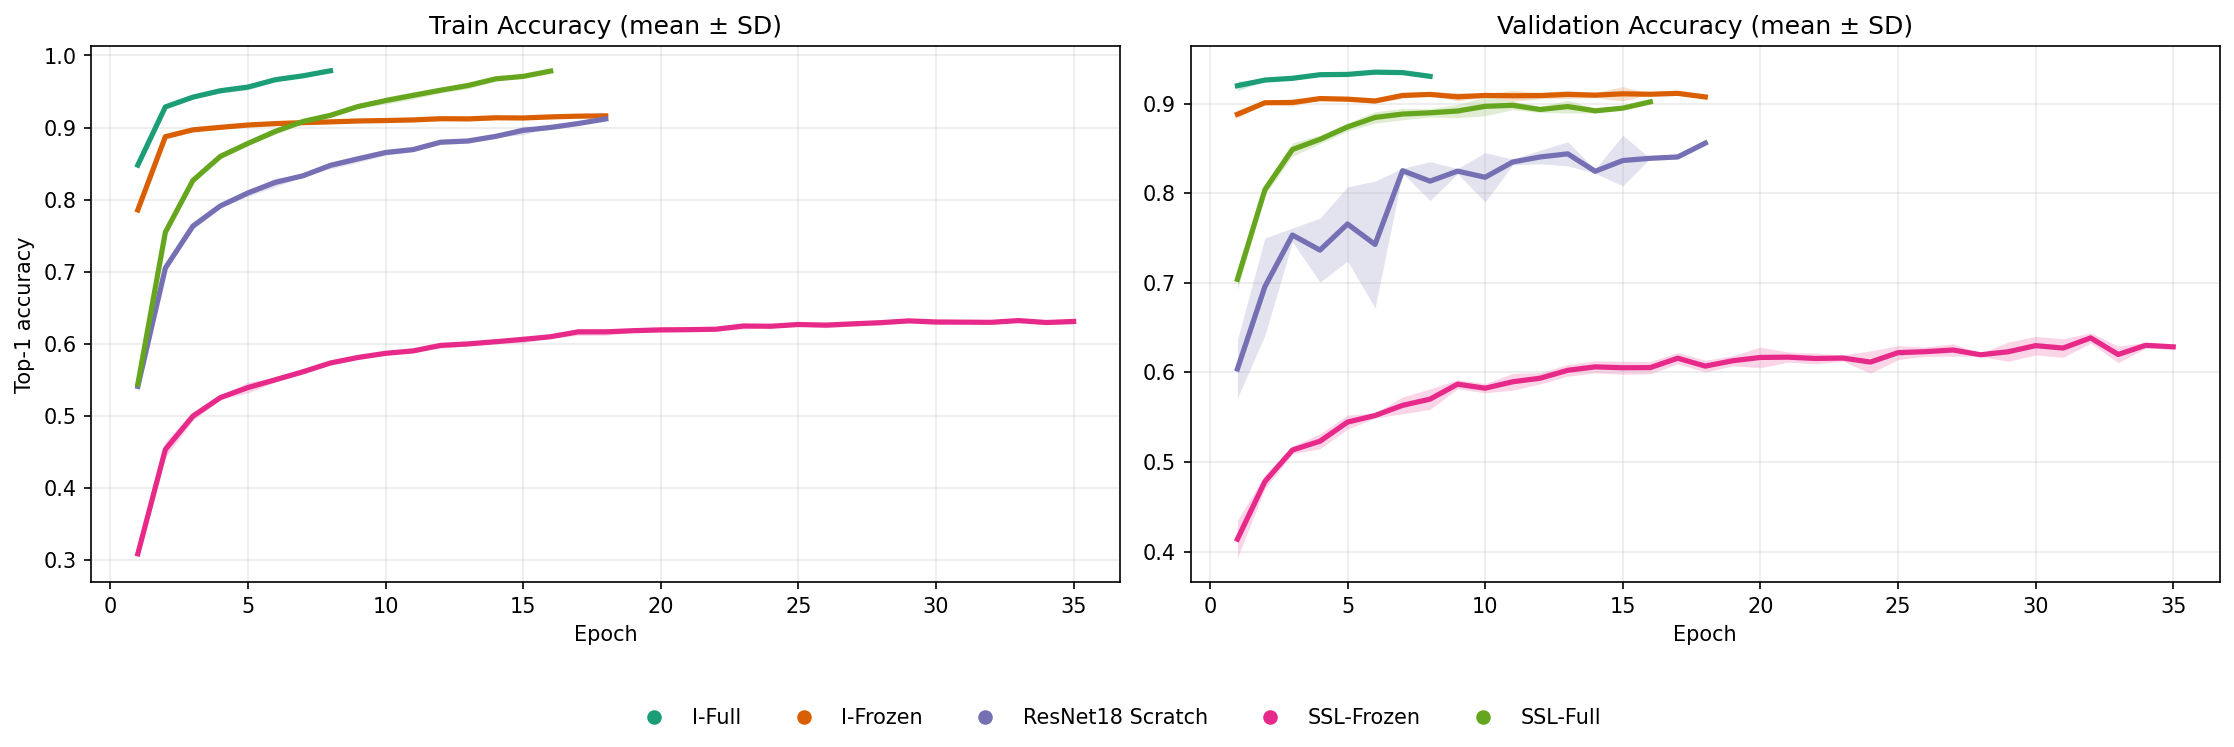

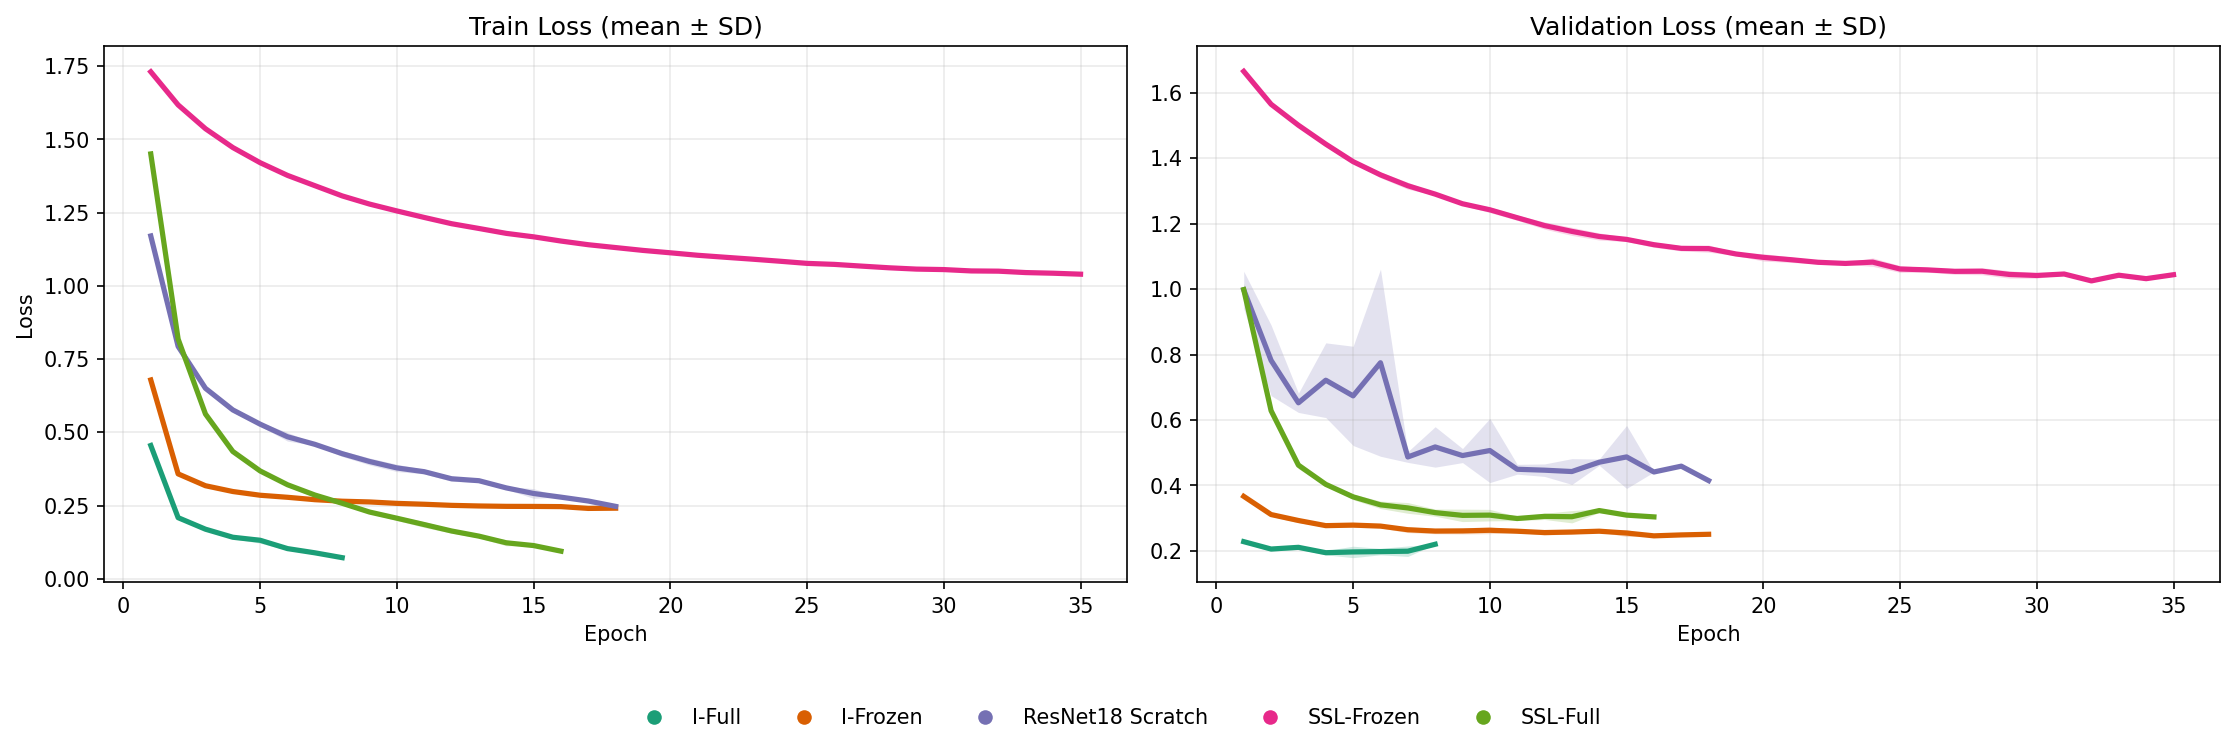

In [73]:
fig = figure_train_validation_curves(results, metric="accuracy")
fig.savefig("train_val_accuracy.png", bbox_inches="tight", dpi=300)
plt.show()

fig = figure_train_validation_curves(results, metric="loss")
fig.savefig("train_val_loss.png", bbox_inches="tight", dpi=300)
plt.show()

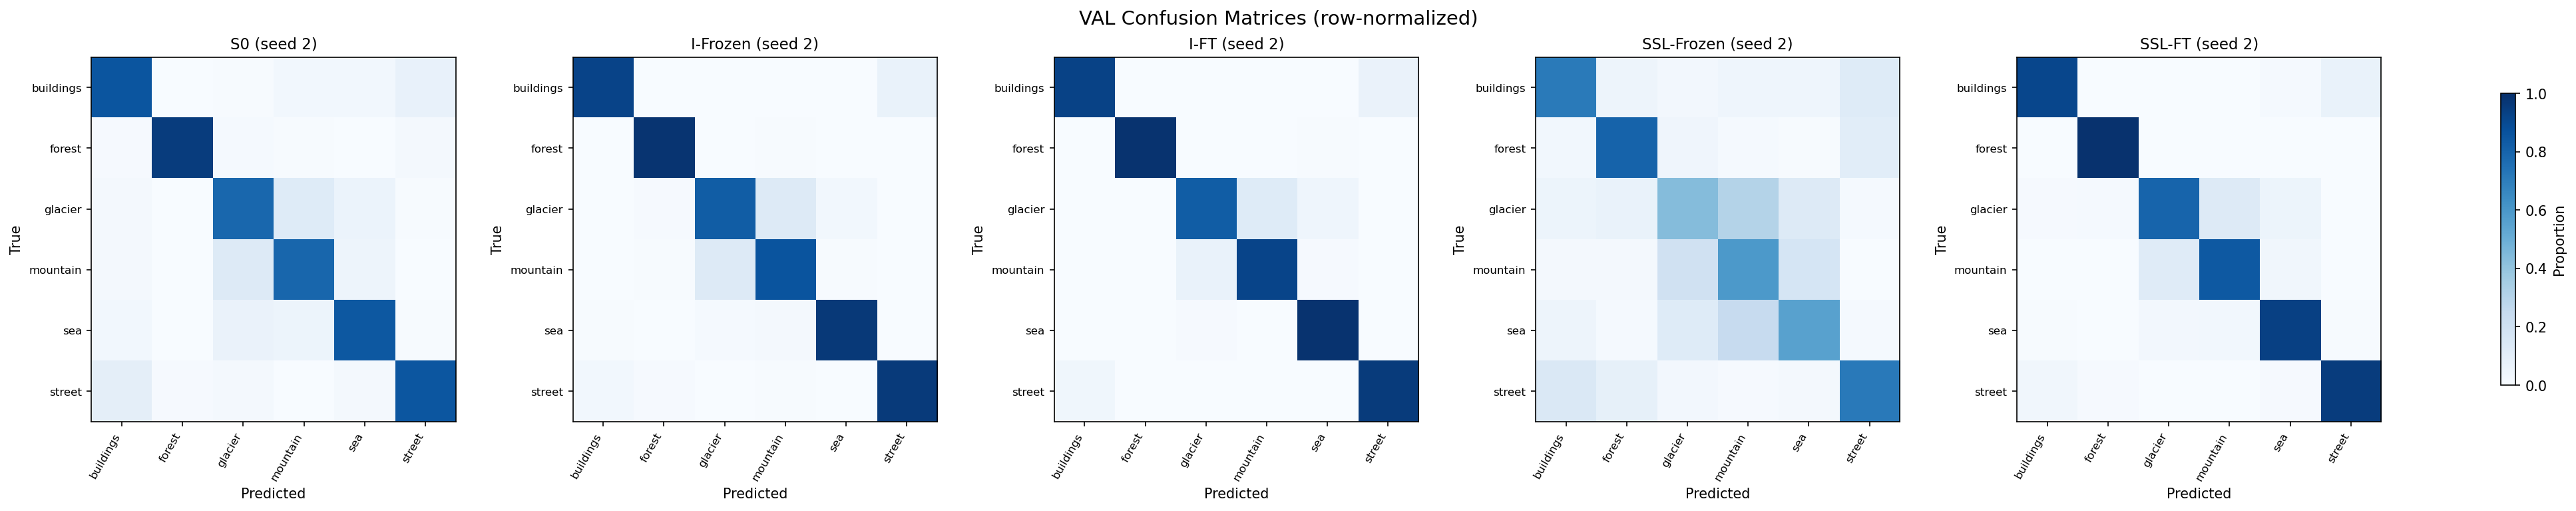

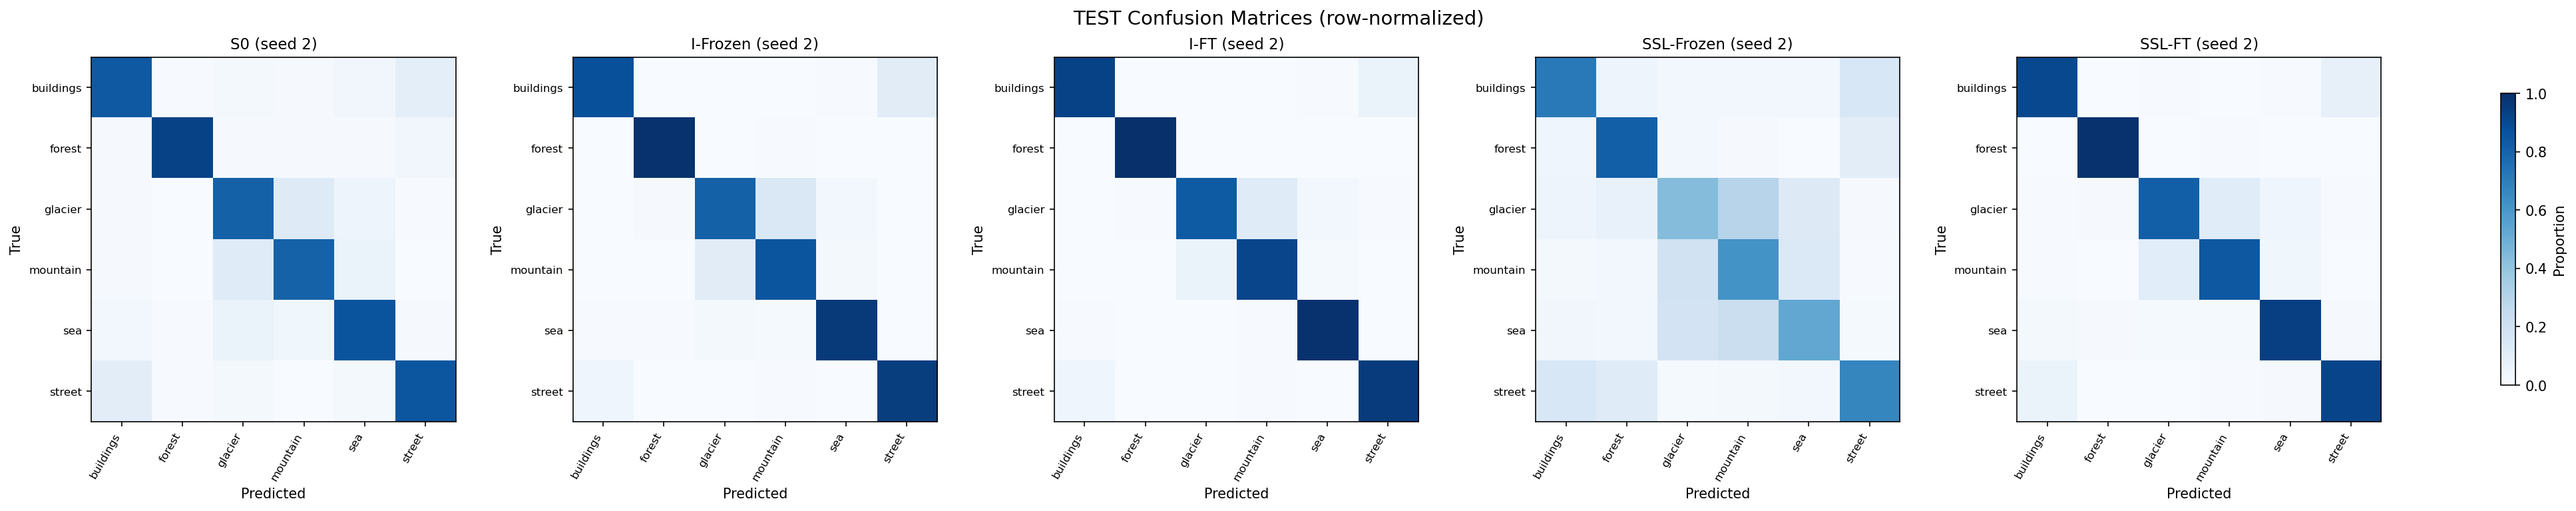

In [77]:
model_types = [
    "model_scratch",
    "imagenet_pretrained_frozen",
    "imagenet_pretrained_fine_tune",
    "ssl_pretrained_fine_tune_frozen",
    "ssl_pretrained_fine_tune_full"
]

name_map = {
    "model_scratch": "S0",
    "imagenet_pretrained_frozen": "I-Frozen",
    "imagenet_pretrained_fine_tune": "I-FT",
    "ssl_pretrained_fine_tune_frozen": "SSL-Frozen",
    "ssl_pretrained_fine_tune_full": "SSL-FT",
}

dic=pd.read_pickle("/users/jmatthia/deep_learning/models/confusion_matrices.pkl")

class_names = val_loader.dataset.dataset.classes

plot_cm_grid(split="VAL", normalize=True, model_types=model_types, confusion_matrix_dictionary=dic, name_map=name_map,class_names=class_names)
plt.savefig("Validation_matrix.png", bbox_inches="tight", dpi=300)
plt.show()
plot_cm_grid(split="TEST", normalize=True, model_types=model_types, confusion_matrix_dictionary=dic, name_map=name_map,class_names=class_names)
plt.savefig("Test_matrix.png", bbox_inches="tight", dpi=300)
plt.show()
